**Author**: Aatif Khan Pathan  
**Project**: Stock Price Prediction

Time-series problem using LSTM

In [1]:
!pip install yfinance

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import yfinance as yf

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
device = 'cuda' if torch.cuda.is_available() else 'cpu'

Structure of TSDtataLoader class:
* args: ticker, start, end
* method: download(), show(), train_test_split(), create_sequence()
* **download():** *args: [none]*, downloads and returns the dataset in data, date
* **show():** plot the data vs date
* **train_test_split():** *args: [data, train_frac, lookback]*, return train-test dataset
* **create_sequence():** *args: [data, date, lookback]*, return x,y sequence.

In [61]:
class TSDataLoader:
    """
    Loads the data of stocks from Yahoo Finance.
    """

    def __init__(self, ticker, start, end):
        """
        Args:
            ticks: name stock
            start: start date
            end: last date
        """

        self.ticker = ticker
        self.start = start
        self.end = end
        self.scaler = MinMaxScaler()

    def download(self):
        print(f"Downloading the data for {self.ticker}...")
        df = yf.download(self.ticker, start = self.start, end = self.end)

        # Using closing price
        self.data = df['Close'].values.reshape(-1,1)
        self.dates = df.index

        print(f'{len(self.data)} days of Data is downloaded. ✅')

        return self.data

    def show_chart(self):
        plt.figure(figsize = (12,6))
        plt.plot(self.dates, self.data)
        plt.xlabel('Days')
        plt.ylabel('Closing Price')
        plt.title(f'{self.ticker} price trend')
        plt.show()


    def create_sequence(self,data,lookback=60):
        x, y = [], []
        for i in range(lookback, len(data)):
            x.append(data[i-lookback:i,0])
            y.append(data[i,0])

        return np.array(x), np.array(y)

    def train_test_split(self,train_split=0.8, lookback=60):

        # Normalize the data
        norm_data = self.scaler.fit_transform(self.data)

        # train- test split
        train_size = int(len(self.data)* train_split)
        train_data = norm_data[: train_size]
        test_data = norm_data[train_size - lookback:]

        # generate sequences
        X_train, Y_train = self.create_sequence(train_data)
        X_test, Y_test = self.create_sequence(test_data)

        # Reshape for LSTM: (samples, timesteps, features)
        X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
        X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

        print("Dataset prepared")
        print(f'\nTrain: {X_train.shape[0]} sequence')
        print(f'Test: {X_test.shape[0]} sequence')
        return  X_train, Y_train, X_test, Y_test, train_size


In [100]:
loader = TSDataLoader('^NSEI','2010-01-01','2026-03-13')
data = loader.download()

/tmp/ipykernel_6564/3700848753.py:21: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(self.ticker, start = self.start, end = self.end)
[*********************100%***********************]  1 of 1 completed

3977 days of Data is downloaded. ✅


In [101]:
x_train, y_train, x_test, y_test, train_size = loader.train_test_split()

Dataset prepared

Train: 3121 sequence
Test: 796 sequence


In [84]:
class LSTMForecaster(nn.Module):
    """ LSTM model for timer series forecasting"""

    def __init__(self, input_dim, hidden_dim, dropout = 0.2, num_layers=2):
        """
        Args:
            input_dim: input features
            hidden_dim: hidden layer size/ dimension
            num_layers: number of LSTM layers
            dropout: Dropout rate

        """
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # network layers
        self.LSTM = nn.LSTM(self.input_dim, self.hidden_dim, dropout = dropout, num_layers = self.num_layers, batch_first=True)
        self.fc = nn.Linear(self.hidden_dim, self.input_dim)

    def forward(self, x):
        """
        Forward pass

        Args:
            x: input tensor (batch_size, seq_len, features)
        Return:
            predictions: (batch, features)
        """

        #initialize
        h0 = torch.zeros((self.num_layers, x.shape[0],self.hidden_dim)).to(x.device)
        c0 = torch.zeros((self.num_layers, x.shape[0],self.hidden_dim)).to(x.device)

        out, _ = self.LSTM(x,(h0,c0))
        output = out[:,-1,:]

        prediction = self.fc(output)

        return prediction


In [102]:
model = LSTMForecaster(input_dim = 1, hidden_dim = 128, num_layers = 2)

In [86]:
class LSTMTrainer:
    """ Train the LSTM forcaster"""

    def __init__(self, model, optimizer, loss_fn, epochs = 50, lr = 0.001, batch_size = 32, device='cpu'):
        self.model = model.to(device)
        self.device = device
        self.epochs = epochs
        self.lr = lr
        self.optim = optimizer
        self.loss_fn = loss_fn
        self.model = model.to(device)
        self.batch_size = batch_size

        self.train_losses = []
        self.val_losses = []

    def train(self, x_trian,y_train, x_test, y_test):

        # convert to pytorch tensor
        X_train = torch.FloatTensor(x_train)
        Y_train = torch.FloatTensor(y_train).reshape(-1,1)
        X_test = torch.FloatTensor(x_test)
        Y_test = torch.FloatTensor(y_test).reshape(-1,1)

        train_dataset = TensorDataset(X_train,Y_train)
        dataloader = DataLoader(train_dataset, batch_size = self.batch_size, shuffle=True)

        print("="*90)
        print("Training star...🚀")
        print("="*90)
        print(f"Epochs: {self.epochs}")
        print(f"Batch size: {self.batch_size}")
        print(f"Learning rate: {self.lr}")
        print(f"{'='*90}\n")

        for epoch in range(self.epochs):
            self.model.train()
            losses = 0

            for x,y in dataloader:
                x = x.to(self.device)
                y = y.to(self.device)

                # forward pass
                pred = self.model(x)
                loss = self.loss_fn(pred,y)
                losses += loss.item()

                # backward pass
                self.optim.zero_grad()
                loss.backward()

                # update grads
                self.optim.step()

            avg_train_loss = losses/len(dataloader)
            self.train_losses.append(avg_train_loss)

            # test the model performance
            self.model.eval()
            with torch.no_grad():
                out = self.model(X_test.to(self.device))
                test_loss = self.loss_fn(out,Y_test.to(self.device))
                self.val_losses.append(test_loss.item())

            # Show progress every 10 epochs
            if (epoch +1) %10 == 0:
                print(f'Epoch [{epoch+1}/{self.epochs}] '
                      f'Train Loss: {avg_train_loss:.6f}'
                    f' val Loss: {test_loss.item():.6f}')

        print("="*90)
        print("Training Completed ✅")
        print("="*90)

    def predict(self,x):
        self.model.eval()
        with torch.no_grad():
            X_tensor = torch.FloatTensor(x).to(self.device)
            pred =self.model(X_tensor)
        return pred

    def plot_training_curve(self):

        plt.figure(figsize = (9,6))
        plt.plot(self.train_losses,label= 'Training Loss')
        plt.plot(self.val_losses, label= 'Validation Loss')
        plt.xlabel('Epochs')
        plt.ylabel('Loss (MSE)')
        plt.title('Training History')
        plt.legend()
        plt.grid(True)
        plt.show()


In [103]:
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)
loss_fn = nn.MSELoss()

In [104]:
trainer = LSTMTrainer(model,optimizer=optimizer,loss_fn=loss_fn,epochs=150,batch_size=32, device=device)

In [105]:
trainer.train(x_train,y_train,x_test,y_test)


Training star...🚀
Epochs: 150
Batch size: 32
Learning rate: 0.001

Epoch [10/150] Train Loss: 0.000159val Loss: 0.000345
Epoch [20/150] Train Loss: 0.000129val Loss: 0.000559
Epoch [30/150] Train Loss: 0.000105val Loss: 0.000671
Epoch [40/150] Train Loss: 0.000114val Loss: 0.001603
Epoch [50/150] Train Loss: 0.000083val Loss: 0.000852
Epoch [60/150] Train Loss: 0.000067val Loss: 0.001158
Epoch [70/150] Train Loss: 0.000068val Loss: 0.001284
Epoch [80/150] Train Loss: 0.000062val Loss: 0.000834
Epoch [90/150] Train Loss: 0.000066val Loss: 0.001665
Epoch [100/150] Train Loss: 0.000052val Loss: 0.000618
Epoch [110/150] Train Loss: 0.000050val Loss: 0.003597
Epoch [120/150] Train Loss: 0.000046val Loss: 0.001496
Epoch [130/150] Train Loss: 0.000044val Loss: 0.001708
Epoch [140/150] Train Loss: 0.000048val Loss: 0.002353
Epoch [150/150] Train Loss: 0.000047val Loss: 0.000785
Training Completed ✅


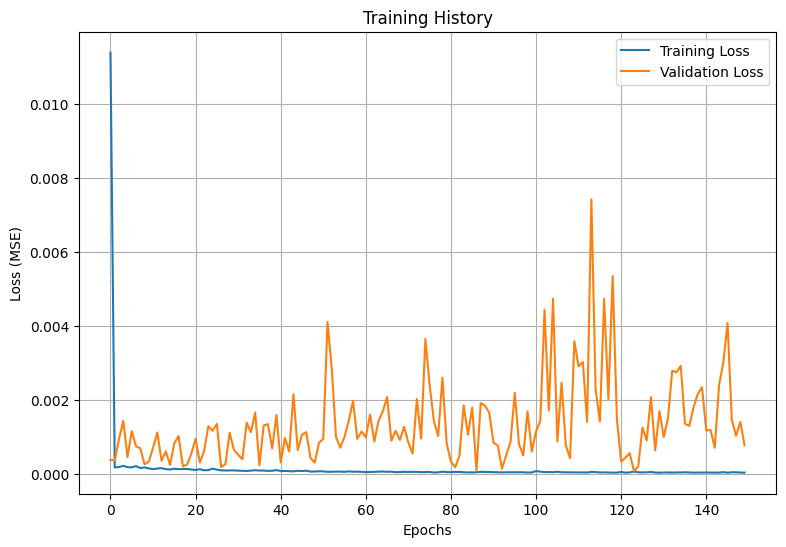

In [106]:
trainer.plot_training_curve()

In [107]:
class EvaluateForcast:
    """ Evaluate Time Seires forcaste"""

    def __init__(self,scaler):
        self.scaler = scaler

    def calculate_metrices(self, y_true, y_pred):
        """Calculate forecasting matrics"""

        # Inverse transform to original scale
        y_true_orig = self.scaler.inverse_transform(y_true.reshape(-1,1))
        y_pred_orig = self.scaler.inverse_transform(y_pred.reshape(-1,1))

        # Calculate metrics
        mae = mean_absolute_error(y_true_orig, y_pred_orig)
        rmse = np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))
        mape = np.mean(np.abs((y_true_orig - y_pred_orig) / y_true_orig)) * 100
        r2 = r2_score(y_true_orig, y_pred_orig)

        print(f"\n{'='*60}")
        print("FORECASTING METRICS")
        print(f"{'='*60}")
        print(f"MAE (Mean Absolute Error):  ${mae:.2f}")
        print(f"RMSE (Root Mean Squared):   ${rmse:.2f}")
        print(f"MAPE (Mean Absolute %):     {mape:.2f}%")
        print(f"R² Score:                   {r2:.4f}")
        print(f"{'='*60}\n")

        return {
            'mae': mae,
            'rmse': rmse,
            'mape': mape,
            'r2': r2
        }

    def plot_predictions(self, y_true, y_pred, dates=None, title='Predictions'):
        """Plot actual vs predicted"""

        # Inverse transform
        y_true_orig = self.scaler.inverse_transform(
y_true.reshape(-1, 1)
        )
        y_pred_orig = self.scaler.inverse_transform(
y_pred.reshape(-1, 1)
)

        plt.figure(figsize=(15, 6))

        if dates is not None:
            plt.plot(dates, y_true_orig, label='Actual', linewidth=2)
            plt.plot(dates, y_pred_orig, label='Predicted', linewidth=2, alpha=0.7)
        else:
            plt.plot(y_true_orig, label='Actual', linewidth=2)
            plt.plot(y_pred_orig, label='Predicted', linewidth=2, alpha=0.7)

        plt.title(title)
        plt.xlabel('Time')
        plt.ylabel('Price ($)')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    def forecast_future(self, model, last_sequence, steps=30):
        """
        Forecast future values

        Args:
            model: Trained LSTM model
            last_sequence: Last N values (lookback window)
            steps: Number of future steps to predict

        Returns:
            predictions: Future predictions
        """
        predictions = []
        current_sequence = last_sequence.copy()

        model.eval()

        for _ in range(steps):
            # Prepare input
            X = torch.FloatTensor(current_sequence).reshape(1, -1, 1).to(device)

            # Predict next value
            with torch.no_grad():
                next_pred = model(X).item()

            predictions.append(next_pred)

            # Update sequence: remove first, add prediction
            current_sequence = np.append(current_sequence[1:], next_pred)

        # Inverse transform to original scale
        predictions_orig = self.scaler.inverse_transform(
            np.array(predictions).reshape(-1, 1)
        )

        return predictions_orig

    def plot_forecast(self, historical_data, forecast, historical_dates=None):
        """Plot historical data with forecast"""

        plt.figure(figsize=(15, 6))

        # Historical data
        if historical_dates is not None:
            plt.plot(historical_dates, historical_data,
                    label='Historical', linewidth=2)

            # Generate future dates
            last_date = historical_dates[-1]
            future_dates = pd.date_range(
                start=last_date + pd.Timedelta(days=1),
                periods=len(forecast)
            )

            plt.plot(future_dates, forecast,
                    label='Forecast', linewidth=2,
                    linestyle='--', color='red')
        else:
            plt.plot(historical_data, label='Historical', linewidth=2)

            future_x = range(len(historical_data),
                           len(historical_data) + len(forecast))
            plt.plot(future_x, forecast,
                    label='Forecast', linewidth=2,
                    linestyle='--', color='red')

        plt.title('Stock Price Forecast (30 Days)')
        plt.xlabel('Date')
        plt.ylabel('Price ($)')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()



In [108]:
evaluator = EvaluateForcast(loader.scaler)

In [109]:
y_pred = trainer.predict(x_test)
metrics = evaluator.calculate_metrices(y_test, y_pred.cpu().numpy())


FORECASTING METRICS
MAE (Mean Absolute Error):  $491.69
RMSE (Root Mean Squared):   $610.36
MAPE (Mean Absolute %):     2.04%
R² Score:                   0.9512



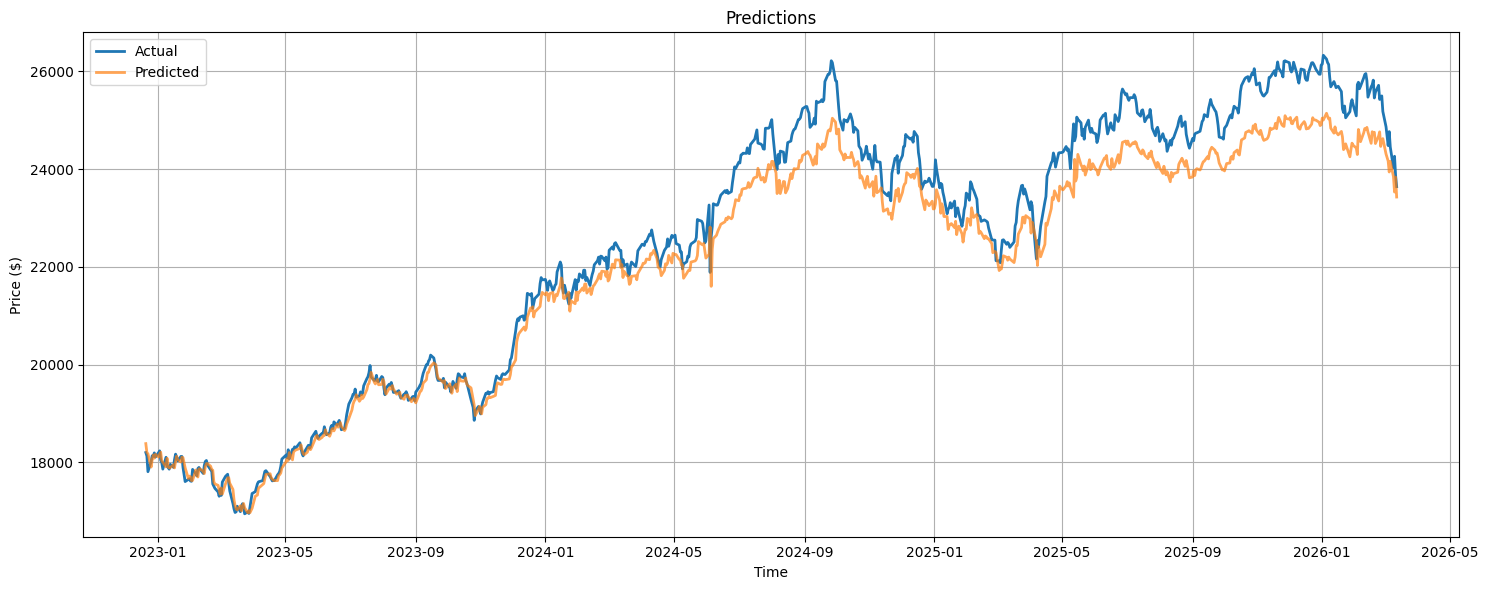

In [110]:
evaluator.plot_predictions(y_test, y_pred.flatten().cpu().numpy(),
                           dates = loader.dates[train_size : train_size + len(y_test)])

In [111]:
last_sequence = x_test[-1, :, 0]  # Last sequence from test set
future_forecast = evaluator.forecast_future(
    model=trainer.model,
    last_sequence=last_sequence,
    steps=30
)

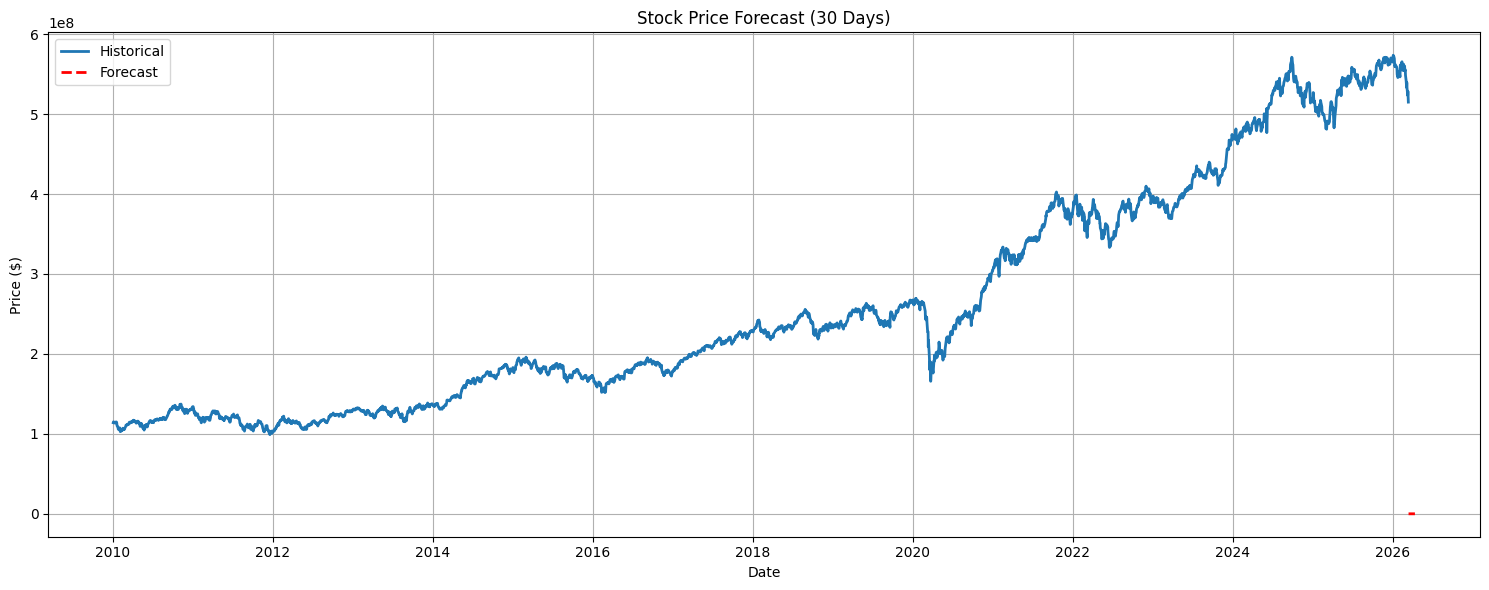

In [112]:
historical_data = loader.scaler.inverse_transform(loader.data)
evaluator.plot_forecast(
    historical_data=historical_data,
    forecast=future_forecast,
    historical_dates=loader.dates
)